### PHASE 1: DATA COLLECTION, ORGANIZATION & PREPROCESSING
### STEP 1: INSTALL & IMPORT LIBRARIES

In [1]:
import os
import zipfile
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from PIL import Image
from collections import Counter
from google.colab import files

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("TensorFlow Version:", tf.__version__)
print("All libraries imported successfully")

TensorFlow Version: 2.19.0
All libraries imported successfully


#### STEP 2: UPLOADING ZIP FILES

In [2]:
print("Please upload parasitized.zip and uninfected.zip")
uploaded = files.upload()

Please upload parasitized.zip and uninfected.zip


Saving parasitized.zip to parasitized.zip
Saving uninfected.zip to uninfected.zip


In [3]:
# STEP 3: EXTRACT ZIP FILES
# Since images are directly inside the zip (no subfolders), we extract straight into named folders

os.makedirs("/content/raw/parasitized", exist_ok=True)
os.makedirs("/content/raw/uninfected", exist_ok=True)

with zipfile.ZipFile("parasitized.zip", 'r') as z:
    z.extractall("/content/raw/parasitized")
print(f"Parasitized images: {len(os.listdir('/content/raw/parasitized'))}")

with zipfile.ZipFile("uninfected.zip", 'r') as z:
    z.extractall("/content/raw/uninfected")
print(f"Uninfected images:  {len(os.listdir('/content/raw/uninfected'))}")

Parasitized images: 499
Uninfected images:  499


In [4]:
# STEP 4: SPLIT INTO TRAIN / VAL (80% - 20%)

for cls in ["parasitized", "uninfected"]:
    os.makedirs(f"/content/dataset/train/{cls}", exist_ok=True)
    os.makedirs(f"/content/dataset/val/{cls}", exist_ok=True)

    images = os.listdir(f"/content/raw/{cls}")
    random.seed(42)
    random.shuffle(images)

    split      = int(len(images) * 0.8)   # 80% train
    train_imgs = images[:split]
    val_imgs   = images[split:]

    for img in train_imgs:
        shutil.copy(f"/content/raw/{cls}/{img}", f"/content/dataset/train/{cls}/{img}")
    for img in val_imgs:
        shutil.copy(f"/content/raw/{cls}/{img}", f"/content/dataset/val/{cls}/{img}")

    print(f"{cls}: {len(train_imgs)} train | {len(val_imgs)} val")

parasitized: 399 train | 100 val
uninfected: 399 train | 100 val


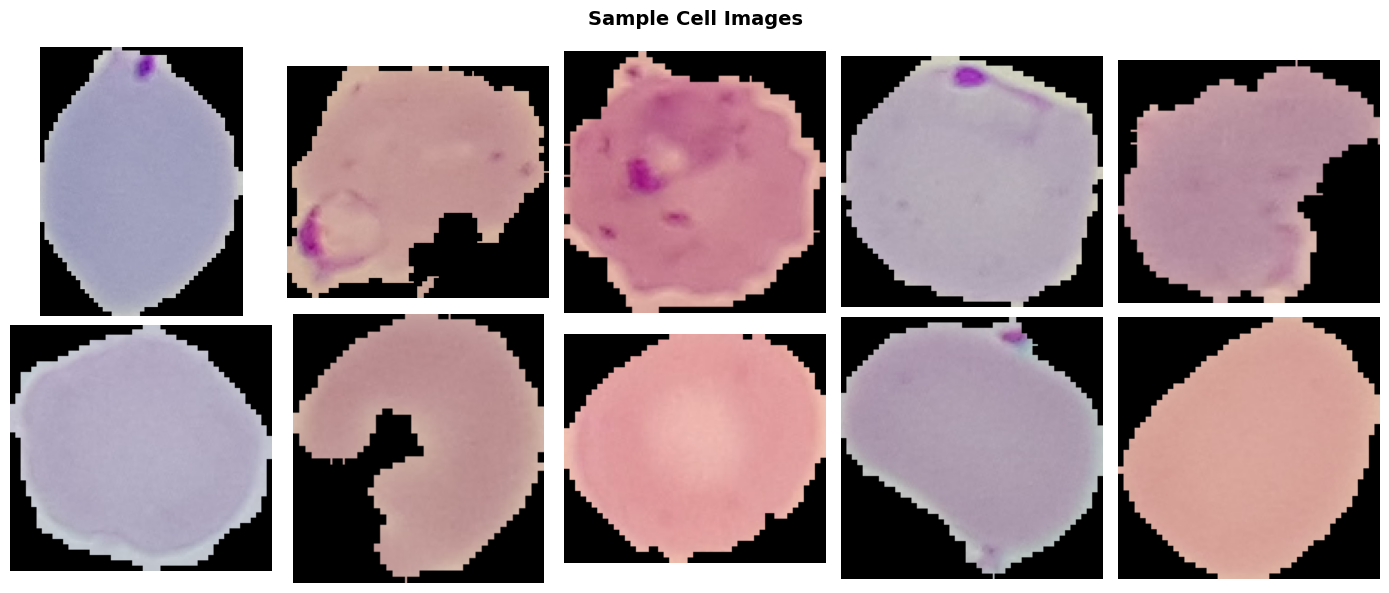

In [5]:
# STEP 5: VISUALIZE SAMPLE IMAGES

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle("Sample Cell Images", fontsize=14, fontweight='bold')

for row, cls in enumerate(["parasitized", "uninfected"]):
    samples = random.sample(os.listdir(f"/content/dataset/train/{cls}"), 5)
    for col, img_name in enumerate(samples):
        img = Image.open(f"/content/dataset/train/{cls}/{img_name}")
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(cls.capitalize(), fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

In [6]:
# STEP 6: CREATE DATA GENERATORS (Preprocessing + Augmentation)

IMG_SIZE   = (128, 128)
BATCH_SIZE = 32

# Training → with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.1
)

# Validation → only normalize, no augmentation
val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    "/content/dataset/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    "/content/dataset/val",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print("Class indices:", train_generator.class_indices)

Found 798 images belonging to 2 classes.
Found 200 images belonging to 2 classes.
Class indices: {'parasitized': 0, 'uninfected': 1}


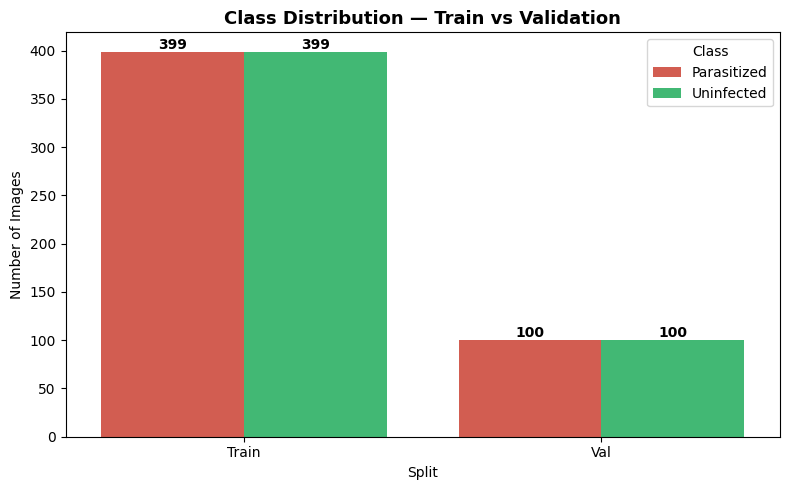

In [7]:
# VISUALIZATION 1: CLASS DISTRIBUTION BAR CHART
import seaborn as sns

splits    = ['Train', 'Train', 'Val', 'Val']
classes   = ['Parasitized', 'Uninfected', 'Parasitized', 'Uninfected']
counts    = [
    len(os.listdir("/content/dataset/train/parasitized")),
    len(os.listdir("/content/dataset/train/uninfected")),
    len(os.listdir("/content/dataset/val/parasitized")),
    len(os.listdir("/content/dataset/val/uninfected"))
]

import pandas as pd
df = pd.DataFrame({"Split": splits, "Class": classes, "Count": counts})

plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="Split", y="Count", hue="Class",
            palette={"Parasitized": "#E74C3C", "Uninfected": "#2ECC71"})
plt.title("Class Distribution — Train vs Validation", fontsize=13, fontweight='bold')
plt.ylabel("Number of Images")
for container in plt.gca().containers:
    plt.bar_label(container, fontweight='bold')
plt.tight_layout()
plt.show()

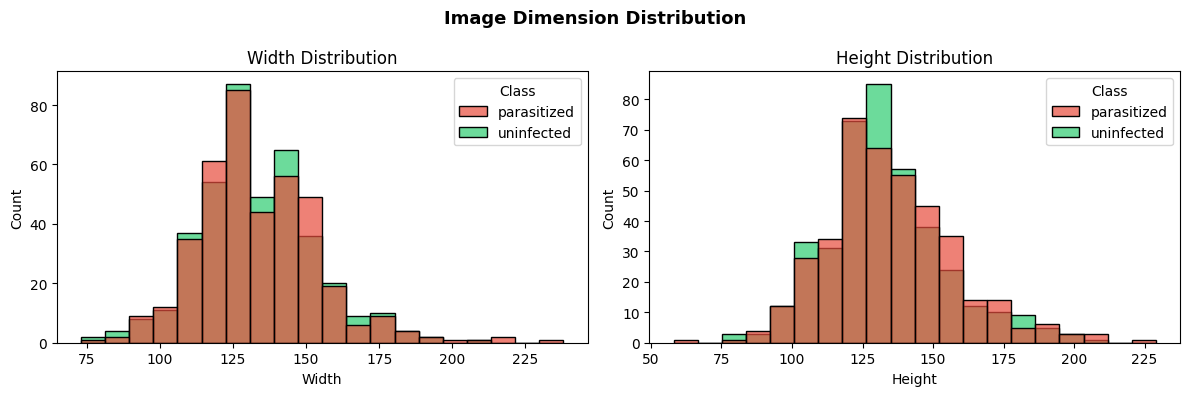

In [8]:
# VISUALIZATION 2: IMAGE SIZE DISTRIBUTION
widths, heights, labels = [], [], []

for cls in ["parasitized", "uninfected"]:
    for img_name in os.listdir(f"/content/dataset/train/{cls}"):
        img = Image.open(f"/content/dataset/train/{cls}/{img_name}")
        w, h = img.size
        widths.append(w)
        heights.append(h)
        labels.append(cls)

df_size = pd.DataFrame({"Width": widths, "Height": heights, "Class": labels})

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Image Dimension Distribution", fontsize=13, fontweight='bold')

sns.histplot(data=df_size, x="Width", hue="Class", bins=20, ax=axes[0],
             palette={"parasitized": "#E74C3C", "uninfected": "#2ECC71"}, alpha=0.7)
axes[0].set_title("Width Distribution")

sns.histplot(data=df_size, x="Height", hue="Class", bins=20, ax=axes[1],
             palette={"parasitized": "#E74C3C", "uninfected": "#2ECC71"}, alpha=0.7)
axes[1].set_title("Height Distribution")

plt.tight_layout()
plt.show()

/tmp/ipykernel_691/3086336665.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_intensity, x="Class", y="Intensity",


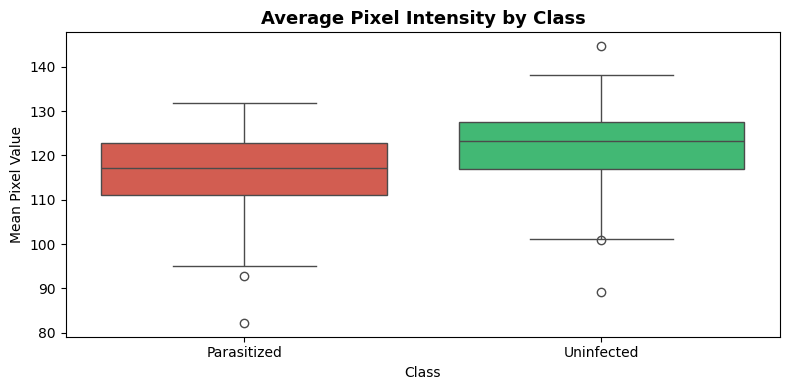

In [9]:
# VISUALIZATION 3: AVERAGE PIXEL INTENSITY PER CLASS
avg_intensities = {"parasitized": [], "uninfected": []}

for cls in ["parasitized", "uninfected"]:
    for img_name in os.listdir(f"/content/dataset/train/{cls}")[:50]:  # sample 50
        img = np.array(Image.open(f"/content/dataset/train/{cls}/{img_name}").resize((128, 128)))
        avg_intensities[cls].append(img.mean())

df_intensity = pd.DataFrame({
    "Intensity": avg_intensities["parasitized"] + avg_intensities["uninfected"],
    "Class"    : ["Parasitized"] * 50 + ["Uninfected"] * 50
})

plt.figure(figsize=(8, 4))
sns.boxplot(data=df_intensity, x="Class", y="Intensity",
            palette={"Parasitized": "#E74C3C", "Uninfected": "#2ECC71"})
plt.title("Average Pixel Intensity by Class", fontsize=13, fontweight='bold')
plt.ylabel("Mean Pixel Value")
plt.tight_layout()
plt.show()

# PHASE 2: MODEL BUILDING & COMPILATION

In [10]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0
from tensorflow.keras.optimizers import Adam

IMG_SIZE    = (128, 128)
IMG_SHAPE   = (128, 128, 3)
EPOCHS      = 20
LR          = 0.001

### MODEL 1: CUSTOM CNN

In [11]:
def create_custom_cnn(img_shape):
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3,3), activation='relu', input_shape=img_shape),
        layers.MaxPooling2D(2,2),

        # Block 2
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),

        # Block 3
        layers.Conv2D(128, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),

        # Classifier
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')   # Binary output
    ], name="CustomCNN")

    model.compile(
        optimizer=Adam(learning_rate=LR),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

### MODEL 2 & 3: TRANSFER LEARNING

In [12]:
def create_transfer_model(model_name, img_shape):

    if model_name == 'MobileNetV2':
        base = MobileNetV2(input_shape=img_shape, include_top=False, weights='imagenet')
        lr   = 0.001
    elif model_name == 'EfficientNetB0':
        base = EfficientNetB0(input_shape=img_shape, include_top=False, weights='imagenet')
        lr   = 0.0001

    base.trainable = False

    model = models.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ], name=model_name)

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

### BUILD ALL 3 MODELS

In [13]:
cnn_model       = create_custom_cnn(IMG_SHAPE)
mobilenet_model = create_transfer_model('MobileNetV2', IMG_SHAPE)
efficient_model = create_transfer_model('EfficientNetB0', IMG_SHAPE)

for model in [cnn_model, mobilenet_model, efficient_model]:
    print(f"\n{'='*45}")
    print(f"  {model.name}")
    print(f"  Total params    : {model.count_params():,}")
    print(f"  Trainable params: {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}")
    print(f"{'='*45}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

  CustomCNN
  Total params    : 3,304,769
  Trainable params: 3,304,769

  MobileNetV2
  Total params    : 2,422,081
  Trainable params: 164,097

  EfficientNetB0
  Total params    : 4,213,668
  Trainable params: 164,097



### PHASE 3: MODEL TRAINING

In [14]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

def get_callbacks(model_name):
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=5,             # Stop if val_loss doesn't improve for 5 epochs
        restore_best_weights=True,
        verbose=1
    )

    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,             # Halve the learning rate
        patience=3,             # After 3 epochs of no improvement
        min_lr=1e-6,
        verbose=1
    )

    checkpoint = ModelCheckpoint(
        filepath=f"/content/{model_name}_best.keras",
        monitor='val_accuracy',
        save_best_only=True,    # Only save when val_accuracy improves
        verbose=1
    )

    return [early_stop, reduce_lr, checkpoint]

In [15]:
def train_model(model, model_name, epochs=20):
    print(f"\n{'='*45}")
    print(f"  Training: {model_name}")
    print(f"{'='*45}\n")

    history = model.fit(
        train_generator,
        epochs=epochs,
        validation_data=val_generator,
        callbacks=get_callbacks(model_name),
        verbose=1
    )
    return history

### plot history

In [16]:
def plot_history(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(f"{model_name} — Training History", fontsize=13, fontweight='bold')

    # Accuracy
    axes[0].plot(history.history['accuracy'],     label='Train Accuracy', color='steelblue')
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   color='orange')
    axes[0].set_title("Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Loss
    axes[1].plot(history.history['loss'],     label='Train Loss', color='steelblue')
    axes[1].plot(history.history['val_loss'], label='Val Loss',   color='orange')
    axes[1].set_title("Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"/content/{model_name}_history.png", dpi=150, bbox_inches='tight')
    plt.show()

## TRAINING


  Training: CustomCNN



/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step - accuracy: 0.5276 - loss: 0.7923
Epoch 1: val_accuracy improved from -inf to 0.48000, saving model to /content/CustomCNN_best.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 15s 352ms/step - accuracy: 0.5277 - loss: 0.7902 - val_accuracy: 0.4800 - val_loss: 0.6928 - learning_rate: 0.0010
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.5484 - loss: 0.6911
Epoch 2: val_accuracy improved from 0.48000 to 0.62500, saving model to /content/CustomCNN_best.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 199ms/step - accuracy: 0.5486 - loss: 0.6911 - val_accuracy: 0.6250 - val_loss: 0.6837 - learning_rate: 0.0010
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.5405 - loss: 0.6898
Epoch 3: val_accuracy did not improve from 0.62500
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 153ms/step - accuracy: 0.5406 - loss: 0.6897 - val_accuracy: 0.6050 - val_loss: 0.6727 - learning_rate: 0.0010
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.

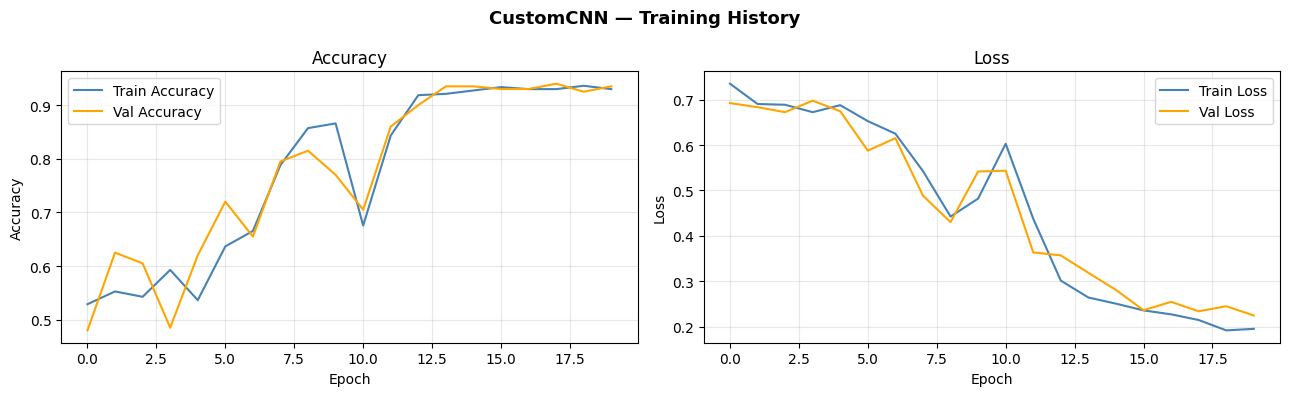


  Training: MobileNetV2

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 672ms/step - accuracy: 0.7351 - loss: 0.5463
Epoch 1: val_accuracy improved from -inf to 0.82500, saving model to /content/MobileNetV2_best.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.7382 - loss: 0.5418 - val_accuracy: 0.8250 - val_loss: 0.3535 - learning_rate: 0.0010
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.8778 - loss: 0.2838
Epoch 2: val_accuracy improved from 0.82500 to 0.83000, saving model to /content/MobileNetV2_best.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 167ms/step - accuracy: 0.8774 - loss: 0.2842 - val_accuracy: 0.8300 - val_loss: 0.3808 - learning_rate: 0.0010
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.8656 - loss: 0.3239
Epoch 3: val_accuracy improved from 0.83000 to 0.86000, saving model to /content/MobileNetV2_best.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 212ms/step - accuracy: 0.8656 - loss: 0.3237 - val_accuracy: 0.8600 - val_loss: 0.2819 - learning

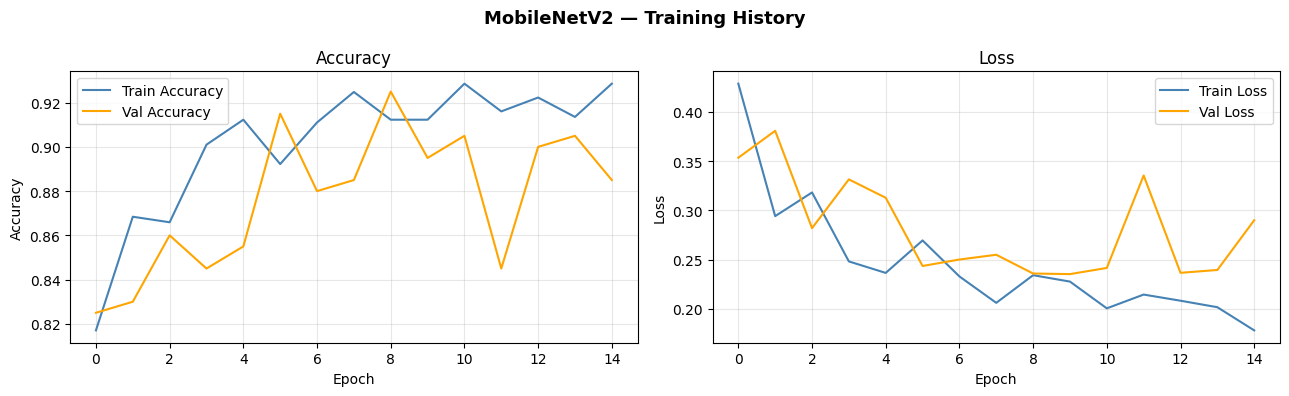


  Training: EfficientNetB0

Epoch 1/20
24/25 ━━━━━━━━━━━━━━━━━━━━ 0s 704ms/step - accuracy: 0.4858 - loss: 0.7013
Epoch 1: val_accuracy improved from -inf to 0.50000, saving model to /content/EfficientNetB0_best.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 56s 1s/step - accuracy: 0.4862 - loss: 0.7011 - val_accuracy: 0.5000 - val_loss: 0.6947 - learning_rate: 1.0000e-04
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.4880 - loss: 0.7013
Epoch 2: val_accuracy did not improve from 0.50000
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 199ms/step - accuracy: 0.4870 - loss: 0.7014 - val_accuracy: 0.5000 - val_loss: 0.6933 - learning_rate: 1.0000e-04
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.5295 - loss: 0.6942
Epoch 3: val_accuracy did not improve from 0.50000
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 158ms/step - accuracy: 0.5293 - loss: 0.6942 - val_accuracy: 0.5000 - val_loss: 0.6933 - learning_rate: 1.0000e-04
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.5010 - l

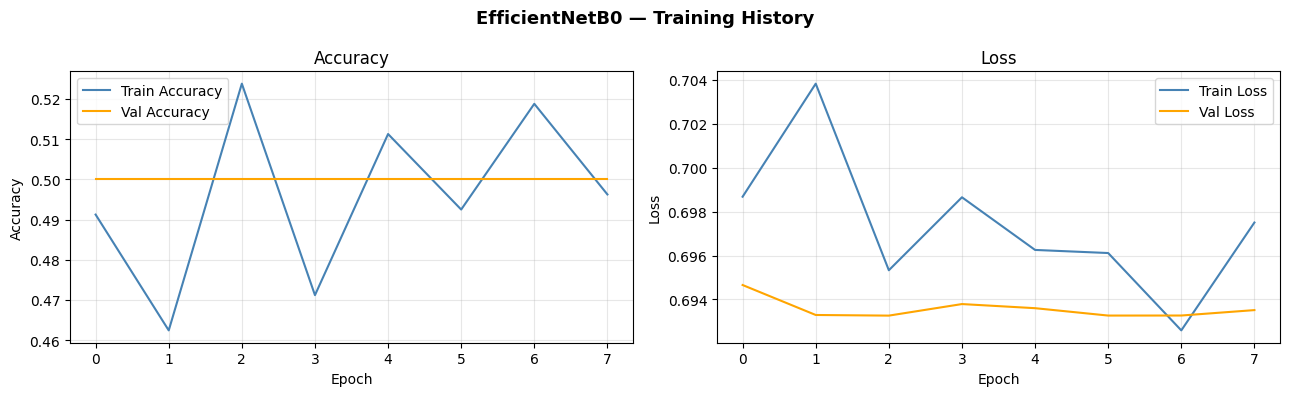

In [17]:
all_histories = {}

models_to_train = {
    'CustomCNN'    : cnn_model,
    'MobileNetV2'  : mobilenet_model,
    'EfficientNetB0': efficient_model
}

for model_name, model in models_to_train.items():
    history = train_model(model, model_name, epochs=20)
    all_histories[model_name] = history
    plot_history(history, model_name)


### FINAL COMPARISON — ALL 3 MODELS


In [21]:
print("\n" + "="*50)
print("         TRAINING RESULTS SUMMARY")
print("="*50)
print(f"  {'Model':<18} {'Best Val Acc':>12} {'Best Val Loss':>14}")
print("-"*50)

for model_name, history in all_histories.items():
    best_acc  = max(history.history['val_accuracy'])
    best_loss = min(history.history['val_loss'])
    print(f"  {model_name:<18} {best_acc:>11.4f}  {best_loss:>13.4f}")

print("="*50)


         TRAINING RESULTS SUMMARY
  Model              Best Val Acc  Best Val Loss
--------------------------------------------------
  CustomCNN               0.9400         0.2243
  MobileNetV2             0.9250         0.2353
  EfficientNetB0          0.5000         0.6933


### MODEL EVALUATION

In [22]:
from sklearn.metrics import (classification_report, confusion_matrix,roc_auc_score, roc_curve)
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
models_to_eval = {
    'CustomCNN'  : cnn_model,
    'MobileNetV2': mobilenet_model
}

In [23]:
def get_predictions(model):
    val_generator.reset()

    preds       = model.predict(val_generator, verbose=1)
    pred_labels = (preds > 0.5).astype(int).flatten()  # 0 or 1
    true_labels = val_generator.classes
    pred_probs  = preds.flatten()                       # Raw probabilities for ROC

    return true_labels, pred_labels, pred_probs

### CONFUSION MATRIX

In [25]:
def plot_confusion_matrix(true_labels, pred_labels, model_name):
    cm = confusion_matrix(true_labels, pred_labels)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Parasitized', 'Uninfected'],
                yticklabels=['Parasitized', 'Uninfected'])
    plt.title(f"{model_name} — Confusion Matrix", fontsize=13, fontweight='bold')
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.savefig(f"/content/{model_name}_confusion_matrix.png", dpi=150)
    plt.show()

### ROC CURVE

In [27]:
def plot_roc_curve(true_labels, pred_probs, model_name):
    fpr, tpr, _ = roc_curve(true_labels, pred_probs)
    auc_score   = roc_auc_score(true_labels, pred_probs)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, color='steelblue', lw=2,label=f"AUC = {auc_score:.4f}")
    plt.plot([0,1], [0,1], 'k--', alpha=0.4)
    plt.title(f"{model_name} — ROC Curve", fontsize=13, fontweight='bold')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"/content/{model_name}_roc_curve.png", dpi=150)
    plt.show()
    return auc_score

## EVALUATION


  Evaluating: CustomCNN
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 129ms/step

Classification Report:
              precision    recall  f1-score   support

 Parasitized       0.91      0.96      0.94       100
  Uninfected       0.96      0.91      0.93       100

    accuracy                           0.94       200
   macro avg       0.94      0.94      0.93       200
weighted avg       0.94      0.94      0.93       200



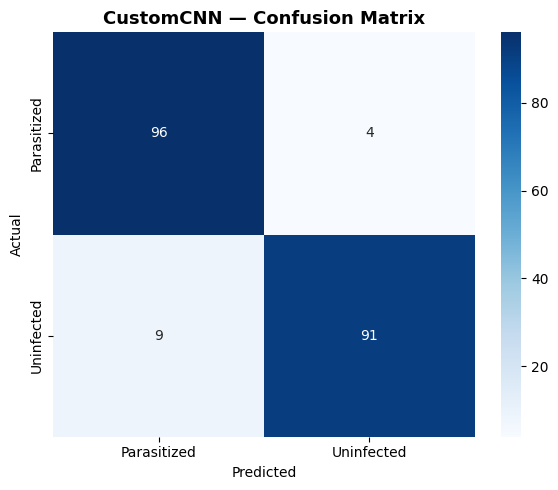

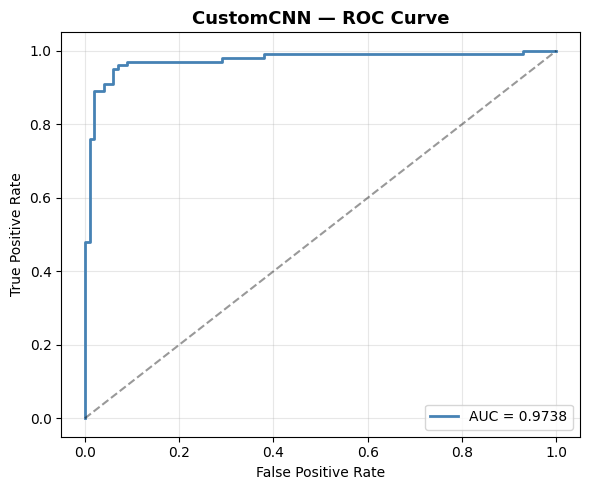


  Evaluating: MobileNetV2
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 710ms/step

Classification Report:
              precision    recall  f1-score   support

 Parasitized       0.93      0.85      0.89       100
  Uninfected       0.86      0.94      0.90       100

    accuracy                           0.90       200
   macro avg       0.90      0.90      0.89       200
weighted avg       0.90      0.90      0.89       200



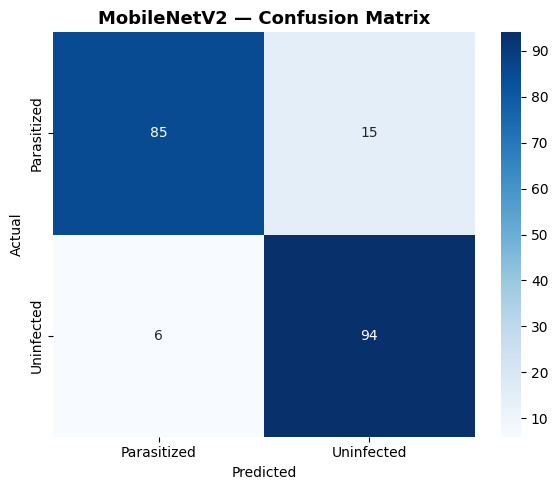

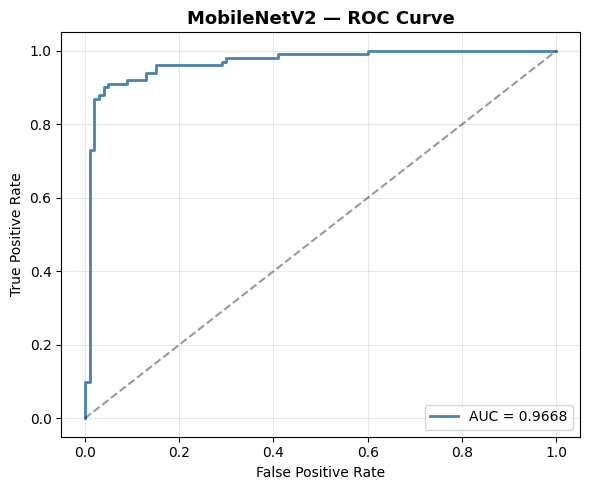

In [28]:
eval_results = {}

for model_name, model in models_to_eval.items():
    print(f"\n{'='*45}")
    print(f"  Evaluating: {model_name}")
    print(f"{'='*45}")

    true_labels, pred_labels, pred_probs = get_predictions(model)

    # Classification Report (precision, recall, f1)
    print("\nClassification Report:")
    print(classification_report(true_labels, pred_labels, target_names=['Parasitized', 'Uninfected']))

    plot_confusion_matrix(true_labels, pred_labels, model_name)
    auc = plot_roc_curve(true_labels, pred_probs, model_name)

    report = classification_report(true_labels, pred_labels,target_names=['Parasitized', 'Uninfected'], output_dict=True)
    eval_results[model_name] = {
        'accuracy' : report['accuracy'],
        'precision': report['weighted avg']['precision'],
        'recall'   : report['weighted avg']['recall'],
        'f1'       : report['weighted avg']['f1-score'],
        'roc_auc'  : auc
    }

In [31]:
print("\n" + "="*70)
print("              FINAL EVALUATION SUMMARY")
print("="*70)
print(f"  {'Model':<18} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8} {'ROC AUC':>9}")
print("-"*70)

for model_name, metrics in eval_results.items():
    print(f"  {model_name:<18}"
          f"  {metrics['accuracy']:.4f}   "
          f"  {metrics['precision']:.4f}   "
          f"  {metrics['recall']:.4f} "
          f"  {metrics['f1']:.4f} "
          f"  {metrics['roc_auc']:.4f}")
print("="*70)
# Pick best model by ROC AUC
best_model_name = max(eval_results, key=lambda x: eval_results[x]['roc_auc'])
best_model = models_to_eval[best_model_name]

print(f"\nBest Model: {best_model_name}")
print(f"     ROC AUC  : {eval_results[best_model_name]['roc_auc']:.4f}")
print(f"     Accuracy : {eval_results[best_model_name]['accuracy']:.4f}")
print(f"\n{best_model_name}")


              FINAL EVALUATION SUMMARY
  Model               Accuracy  Precision   Recall       F1   ROC AUC
----------------------------------------------------------------------
  CustomCNN           0.9350     0.9361     0.9350   0.9350   0.9738
  MobileNetV2         0.8950     0.8982     0.8950   0.8948   0.9668

Best Model: CustomCNN
     ROC AUC  : 0.9738
     Accuracy : 0.9350

CustomCNN


In [32]:
from google.colab import files

cnn_model.save("/content/CustomCNN.keras")
mobilenet_model.save("/content/MobileNetV2.keras")

print("Downloading CustomCNN...")
files.download("/content/CustomCNN.keras")

print("Downloading MobileNetV2...")
files.download("/content/MobileNetV2.keras")

print("Both models downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Both models downloaded!
